### 크로마키

In [2]:
import cv2
import numpy as np
from PIL import Image

def show(image):
    rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    return Image.fromarray(rgb)

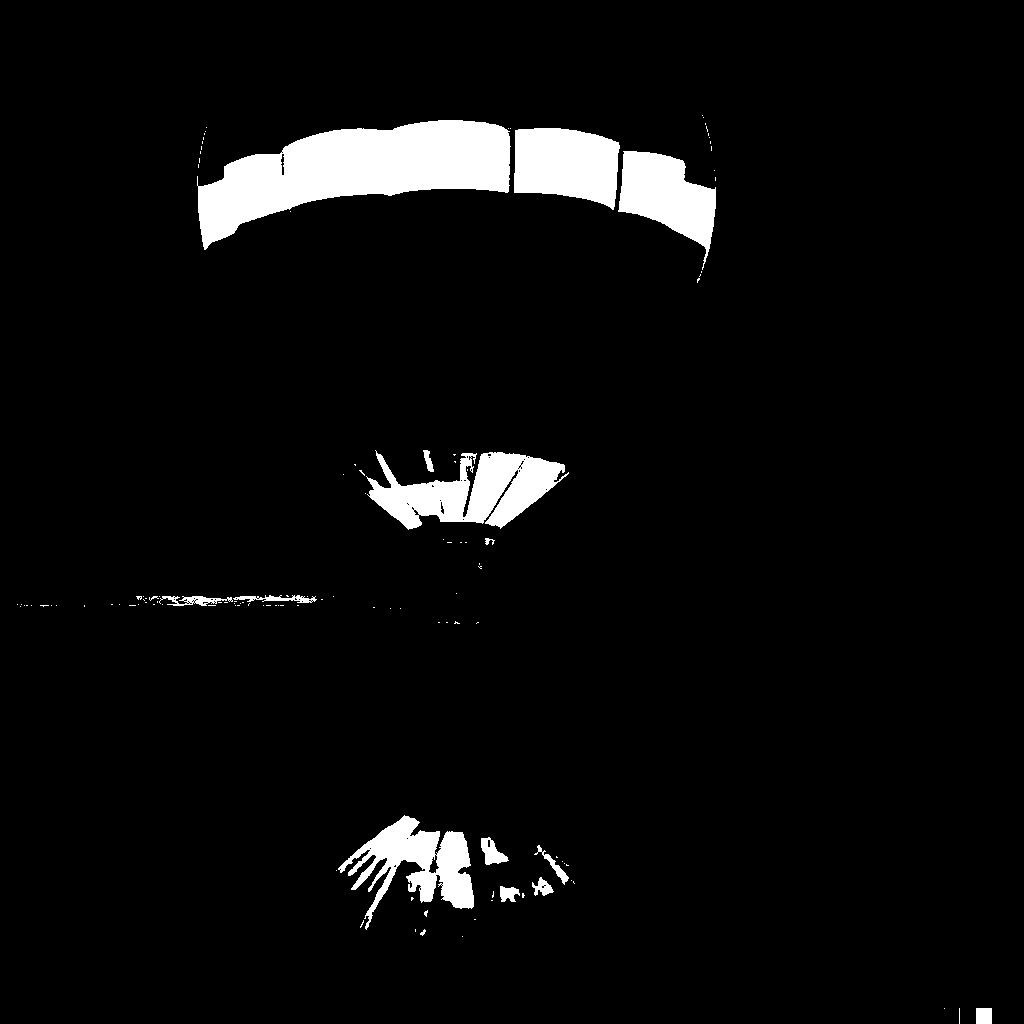

In [3]:
# 특정 색상만 추출
image = cv2.imread('../data/balloon.webp')
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

# HSV에서 H가 40~80, SV는 50~255 사이인 부분만 추출
lower = np.array([40, 50, 50])
upper = np.array([80, 255, 255])
mask = cv2.inRange(hsv, lower, upper)
Image.fromarray(mask)

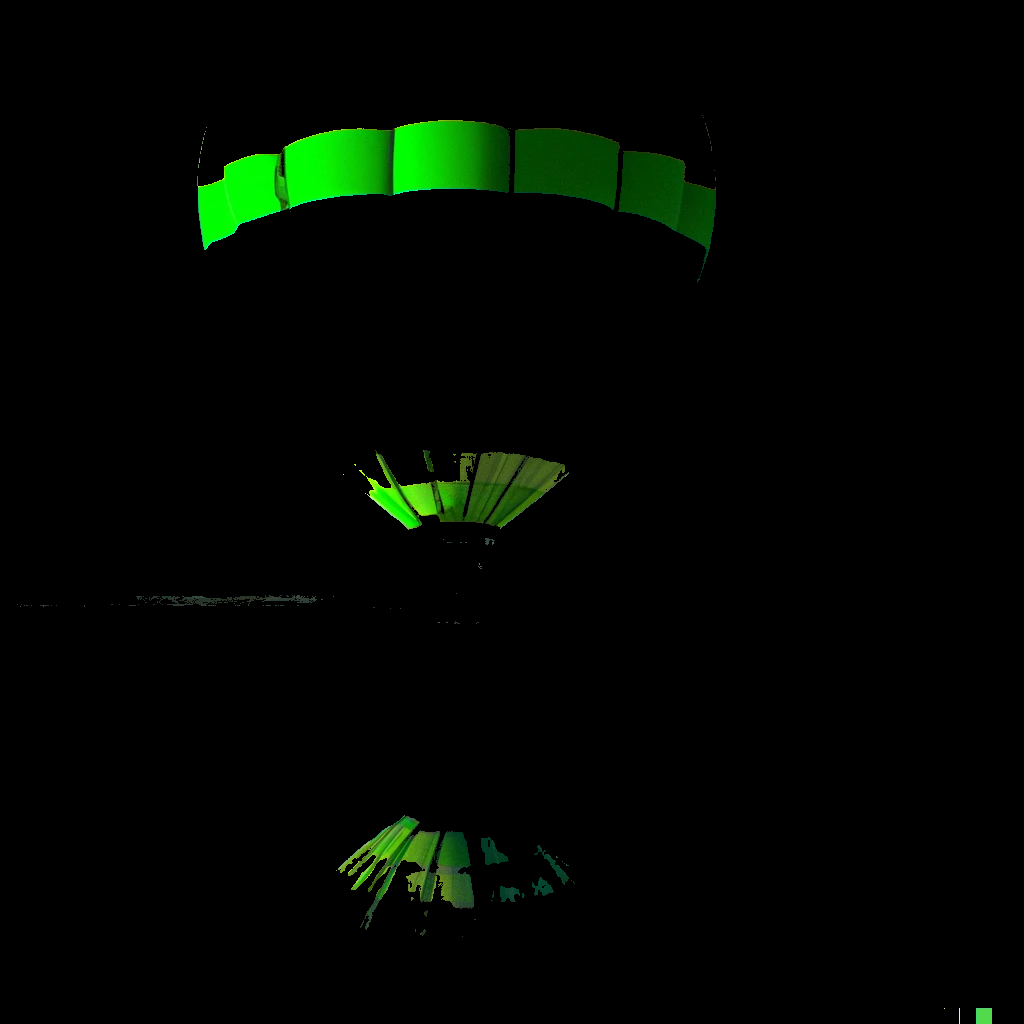

In [4]:
show(cv2.bitwise_and(image, image, mask=mask))

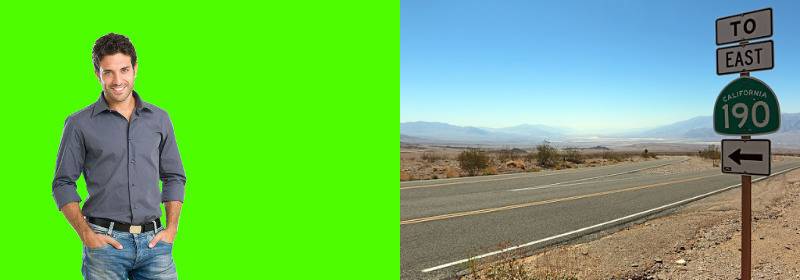

In [5]:
# 크로마키를 이용한 합성(1)
foreground = cv2.imread('../data/chroma-key.jpg')
background = cv2.imread('../data/desert.jpg')

# 배경 크기 리사이즈
height, width = foreground.shape[:2]
background = cv2.resize(background, (width, height))

# 인물 이미지를 HSV로 변환
hsv = cv2.cvtColor(foreground, cv2.COLOR_BGR2HSV)
show(np.concatenate([foreground, background], axis=1))

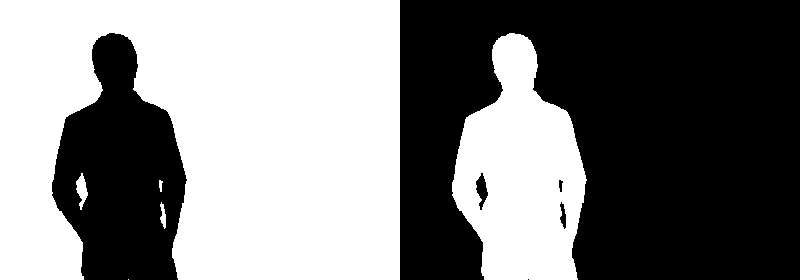

In [6]:
# 크로마키 색 범위
lower_green = np.array([40, 100, 100])
upper_green = np.array([60, 255, 255])

# 마스크 만들기
mask = cv2.inRange(hsv, lower_green, upper_green)
mask_inv = cv2.bitwise_not(mask)

show(np.concatenate([mask, mask_inv], axis=1))

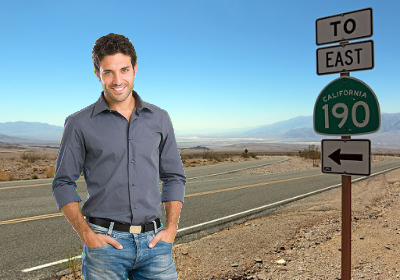

In [7]:
# 전경에서 인물만 뽑기
fg_isolated = cv2.bitwise_and(foreground, foreground, mask=mask_inv)

# 배경에서 인물만큼 잘라내기
bg_isolated = cv2.bitwise_and(background, background, mask=mask)

# 합치기
final_output = cv2.add(fg_isolated, bg_isolated)
show(final_output)